# 🤖 Notebook 03 — Modélisation KNN
## Classification · Régression · Validation · Interprétation

> **Cours mobilisés :** Data Analysis (27 Fév. 2026 — Partie 2 Machine Learning)

---

## Rappel Théorique — K-Nearest Neighbors (KNN)

L'algorithme KNN est un estimateur **non-paramétrique** basé sur la **distance**.
Il n'apprend pas de paramètres explicites — il mémorise les données d'entraînement
et prédit en cherchant les K observations les plus proches.

**Distance euclidienne** (métrique par défaut) :
$$d(\mathbf{x}, \mathbf{x'}) = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2}$$

**Prédiction en classification** (vote majoritaire pondéré) :
$$\hat{y}(\mathbf{x}) = \arg\max_{c} \sum_{i \in \mathcal{N}_K(x)} \frac{\mathbf{1}[y_i = c]}{d(x, x_i)}$$

**Prédiction en régression** (moyenne pondérée) :
$$\hat{y}(\mathbf{x}) = \frac{\sum_{i \in \mathcal{N}_K(x)} \frac{y_i}{d(x, x_i)}}{\sum_{i \in \mathcal{N}_K(x)} \frac{1}{d(x, x_i)}}$$

**Hyperparamètre clé :** K
- K trop petit → **surapprentissage** (overfitting) : le modèle mémorise le bruit
- K trop grand → **sous-apprentissage** (underfitting) : le modèle trop lisse perd l'information
- K optimal → **validation croisée** (5-fold)

**Standardisation obligatoire :**
KNN est basé sur des distances → toutes les features doivent être sur la même échelle.
Sans standardisation, une variable avec de grandes valeurs (ex: MNT_SHADING ≈ 100)
dominerait les distances face à des variables centrées sur 0.

In [1]:
# Installation des dépendances (à exécuter une seule fois)
# Si une librairie manque, décommentez et exécutez cette cellule

# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#     "pandas", "numpy", "scipy", "matplotlib", "seaborn", "scikit-learn"])
# Pour la cartographie (optionnel) :
# subprocess.check_call([sys.executable, "-m", "pip", "install", "geopandas", "shapely"])

# ── Vérification rapide des imports disponibles ────────────────────────
import importlib
required = ["pandas", "numpy", "scipy", "matplotlib", "seaborn", "sklearn"]
for pkg in required:
    status = "✅" if importlib.util.find_spec(pkg) else "❌ MANQUANT"
    print(f"{status}  {pkg}")


✅  pandas
✅  numpy
✅  scipy
✅  matplotlib
✅  seaborn
✅  sklearn


## 1. 📦 Imports & Chargement

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from data_engineering.ingestion  import load_raw
from data_engineering.cleaning   import clean
from modeling.preprocessing      import prepare_full, build_feature_matrix, FEATURES_BASE
from modeling.knn_classifier     import (
    find_best_k, plot_k_selection,
    train_evaluate, plot_confusion_matrix,
    compute_feature_importance
)
from modeling.knn_regressor      import (
    find_best_k_regression, plot_k_regression,
    train_evaluate_regression, plot_regression_results
)

plt.rcParams.update({'figure.dpi': 120})
pd.set_option('display.float_format', '{:.4f}'.format)

# Chargement
df_raw = load_raw(Path('../data/raw/BaseCLD2026.csv'))
df     = clean(df_raw)
print(f'✅ Dataset : {df.shape[0]:,} obs × {df.shape[1]} variables')
print(f'   Taux de détection : {df["DETECTED"].mean()*100:.1f}%')

INFO | 📂 Chargement depuis : ..\data\raw\BaseCLD2026.csv
INFO | ✅ Chargé : 31,126 lignes × 22 colonnes
INFO | 🧹 Démarrage du nettoyage...
INFO |   🔤 Renommage : 17 colonnes renommées
INFO |   📅 Dates converties : ['DATE_OF_SAMPLING', 'DATE_RECORDED', 'DATE_ANALYSIS']
INFO |   🧪 RATE_5B_HYDRO nettoyé (virgules, < seuils)
INFO |   📋 Valeurs manquantes restantes :
COMMU_LAB                  298
SOL_SIMPLE                  74
TYPE_SOL                  2609
DATE_ANALYSIS             2702
RATE_5B_HYDRO               23
HISTOBANANE_HISTO_BAN    17983
MNT_TPI_MEAN                28
MNT_TRI_MEAN                28
MNT_RUGOSITY_MEAN           28
MNT_SHADING_MEAN            28
MNT_EXPOSURE_MEAN           28
MNT_SLOPE_MEAN              28
INFO |   🔍 DETECTED : 10,777 détections / 31,126 (34.6%)
INFO |   📊 CLASS_CONTAMINATION créée (4 niveaux : 0–3)
INFO |   🍌 HISTOBANANE : 17983 valeurs manquantes → 0
INFO | ✅ Nettoyage terminé : 31,126 lignes × 26 colonnes


✅ Dataset : 31,126 obs × 26 variables
   Taux de détection : 34.6%


## 2. 🔧 Préparation des Features

In [3]:
# Préparation complète pour la classification
data_clf = prepare_full(df, task='classification', encode_soil=True)

print('── Résumé de la préparation ────────────────────────────────────')
print(f'  Features    : {data_clf["feature_names"]}')
print(f'  Cible       : {data_clf["target"]}')
print(f'  Train       : {data_clf["n_train"]:,} obs.')
print(f'  Test        : {data_clf["n_test"]:,} obs.')
print(f'  Shape X_train : {data_clf["X_train"].shape}')

INFO |   🎯 Tâche : classification
INFO |   🔢 SOL_SIMPLE encodé → ['Alluvium, Colluvium' 'Andosol' 'Ferralsol' 'Nitisol' 'No data' 'Unknown'
 'Urban area' 'Vertisol']
INFO |   ⚕️  MNT_SLOPE_MEAN : 28 NaN → médiane (17.9023)
INFO |   ⚕️  MNT_TPI_MEAN : 28 NaN → médiane (0.1200)
INFO |   ⚕️  MNT_TRI_MEAN : 28 NaN → médiane (3.8218)
INFO |   ⚕️  MNT_EXPOSURE_MEAN : 28 NaN → médiane (169.3089)
INFO |   ⚕️  MNT_SHADING_MEAN : 28 NaN → médiane (177.1030)
INFO |   ⚕️  MNT_RUGOSITY_MEAN : 28 NaN → médiane (12.0000)
INFO |   ✅ Matrice X : 31,126 obs × 8 features
INFO |   📊 Train : 24,900 obs | Test : 6,226 obs
INFO |   Distribution (train) : {0: 0.6537751004016065, 1: 0.3462248995983936}
INFO |   ⚖️  StandardScaler : μ=[20.229  0.21   4.306]... σ=[13.334  2.579  2.856]...


── Résumé de la préparation ────────────────────────────────────
  Features    : ['MNT_SLOPE_MEAN', 'MNT_TPI_MEAN', 'MNT_TRI_MEAN', 'MNT_EXPOSURE_MEAN', 'MNT_SHADING_MEAN', 'MNT_RUGOSITY_MEAN', 'HISTOBANANE_HISTO_BAN', 'SOL_SIMPLE_ENCODED']
  Cible       : DETECTED
  Train       : 24,900 obs.
  Test        : 6,226 obs.
  Shape X_train : (24900, 8)


### 💬 Lecture — Feature Engineering pour KNN

Les features topographiques (MNT) sont choisies car elles captent :
- La **pente** : les zones planes retiennent davantage les contaminants
- Le **TPI** (Topographic Position Index) : position dans le relief (sommet/vallée)
- Le **TRI** (Terrain Ruggedness Index) : mesure de la rugosité du relief
- L'**exposition** : orientation par rapport au soleil (influence l'évaporation)
- L'**ombrage** : zones ombragées = moins de dégradation photolytique

Le **type de sol** (encodé) est crucial car les Andosols retiennent le chlordécone
différemment des Nitisols ou Ferralsols.

L'**historique bananier** (HISTOBANANE) quantifie le nombre de périodes de culture
intensive — variable proxy de l'exposition historique au pesticide.

## 3. 🎯 KNN Classification — Parcelle Contaminée ?

INFO |   🔍 Recherche du K optimal (range 1–31, cv=5)...


Recherche du K optimal (validation croisée 5-fold)...


INFO |   ✅ Meilleur K = 1 (F1 = 0.8012)
INFO | 📊 Figure exportée → C:\Users\hp\Downloads\chlordecone-project\reports\figures\07_knn_k_selection.png


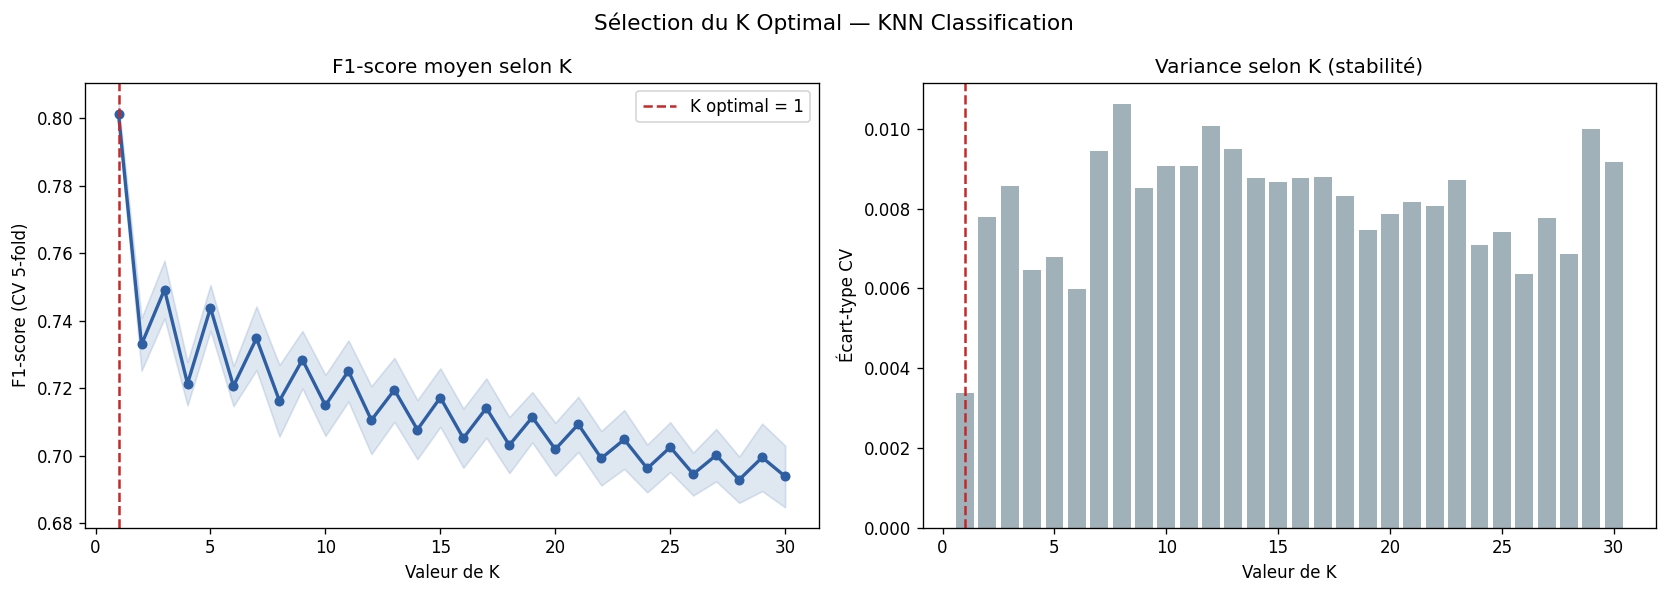


✅ Meilleur K = 1 (F1 = 0.8012)


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

# Votre code de génération de carte ici...
# Sélection du K optimal par validation croisée 5-fold
print('Recherche du K optimal (validation croisée 5-fold)...')
k_results_clf = find_best_k(
    data_clf['X_train'], data_clf['y_train'],
    k_range=range(1, 31), cv=5, scoring='f1'
)
fig = plot_k_selection(k_results_clf, save=True)
plt.show()

print(f'\n✅ Meilleur K = {k_results_clf["best_k"]} (F1 = {k_results_clf["best_f1"]:.4f})')

### 💬 Lecture — Sélection du K Optimal

**Validation croisée 5-fold :**
Le dataset d'entraînement est divisé en 5 parties égales.
Pour chaque K, on entraîne sur 4/5 et évalue sur 1/5, en tournant 5 fois.
Le F1-score moyen (sur 5 évaluations) est reporté avec son écart-type.

**Biais-variance trade-off :**
- **K=1** : overfitting — le modèle mémorise chaque point, F1 train ≈ 1 mais F1 test bas
- **K grand** : underfitting — trop de voisins, on perd la structure locale
- **K optimal** : compromis — maximise le F1 sur données non vues

**F1-score (pondéré) :** Combine précision et rappel.
Préférable à l'accuracy quand les classes sont déséquilibrées.

INFO |   🤖 Entraînement KNN (K=1, metric='euclidean', weights='distance')...
INFO |   Accuracy  : 0.8760
INFO |   F1 (weighted) : 0.8760
INFO |   Precision : 0.8760
INFO |   Recall    : 0.8760
INFO | 📊 Figure exportée → C:\Users\hp\Downloads\chlordecone-project\reports\figures\08_knn_confusion_metrics.png


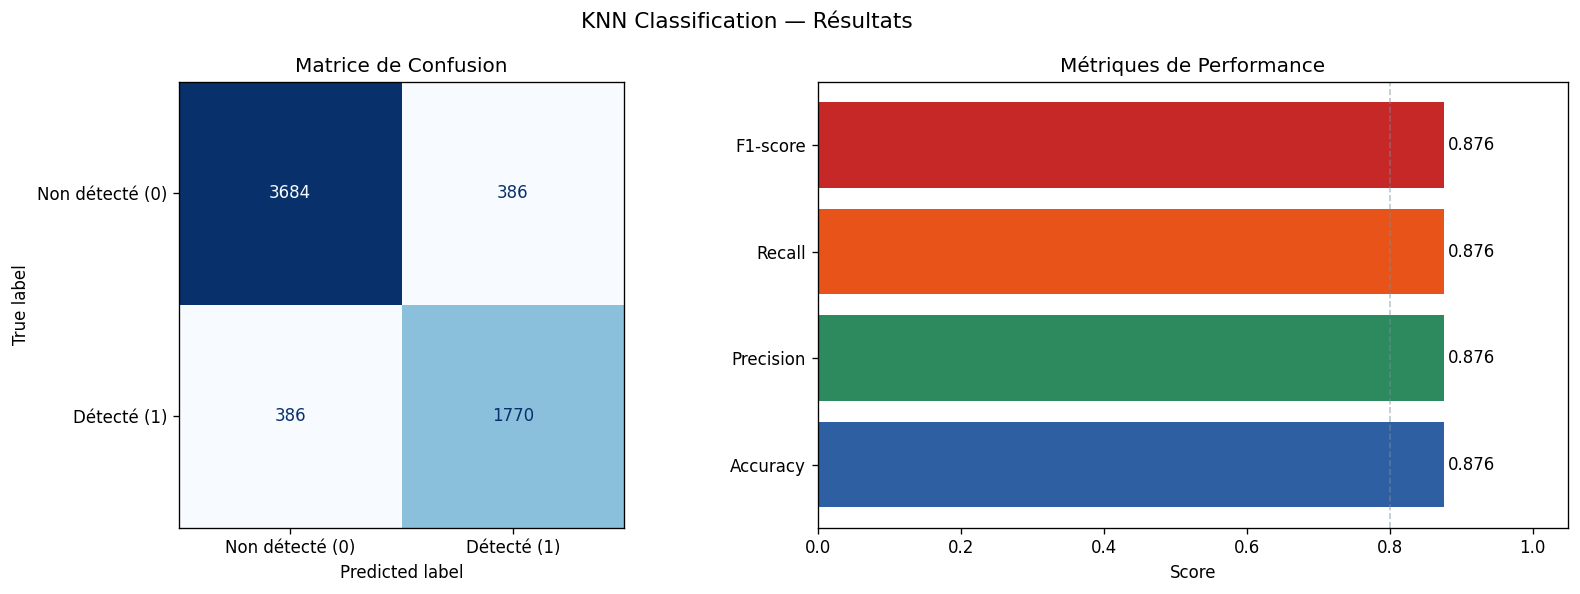

In [5]:
# Entraînement du modèle final
results_clf = train_evaluate(
    data_clf['X_train'], data_clf['X_test'],
    data_clf['y_train'], data_clf['y_test'],
    best_k=k_results_clf['best_k'],
    feature_names=data_clf['feature_names']
)
fig = plot_confusion_matrix(results_clf, save=True)
plt.show()

In [6]:
# Rapport de classification complet
print('── Rapport de Classification ───────────────────────────────────')
report_df = pd.DataFrame(results_clf['report']).T
print(report_df.round(4).to_string())

── Rapport de Classification ───────────────────────────────────
              precision  recall  f1-score   support
0                0.9052  0.9052    0.9052 4070.0000
1                0.8210  0.8210    0.8210 2156.0000
accuracy         0.8760  0.8760    0.8760    0.8760
macro avg        0.8631  0.8631    0.8631 6226.0000
weighted avg     0.8760  0.8760    0.8760 6226.0000


### 💬 Lecture — Matrice de Confusion & Métriques

**Matrice de confusion :**
- **VP (Vrais Positifs)** : parcelles contaminées correctement identifiées ✅
- **FN (Faux Négatifs)** : contaminées classées 'propres' ⚠️ **erreur la plus dangereuse**
- **FP (Faux Positifs)** : propres classées 'contaminées' (sur-précaution)
- **VN (Vrais Négatifs)** : propres correctement identifiées ✅

**Pour un problème sanitaire :** minimiser les FN est prioritaire sur minimiser les FP.
Un terrain contaminé classé 'propre' représente un risque réel pour la santé humaine.

**F1-score :** Moyenne harmonique de précision et rappel.
$$F_1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}$$

## 4. 📏 KNN Régression — Prédiction du Taux CLD

INFO |   🎯 Tâche : regression
INFO |   🔢 SOL_SIMPLE encodé → ['Alluvium, Colluvium' 'Andosol' 'Ferralsol' 'Nitisol' 'No data' 'Unknown'
 'Urban area' 'Vertisol']
INFO |   ⚕️  MNT_SLOPE_MEAN : 28 NaN → médiane (17.9023)
INFO |   ⚕️  MNT_TPI_MEAN : 28 NaN → médiane (0.1200)
INFO |   ⚕️  MNT_TRI_MEAN : 28 NaN → médiane (3.8218)
INFO |   ⚕️  MNT_EXPOSURE_MEAN : 28 NaN → médiane (169.3089)
INFO |   ⚕️  MNT_SHADING_MEAN : 28 NaN → médiane (177.1030)
INFO |   ⚕️  MNT_RUGOSITY_MEAN : 28 NaN → médiane (12.0000)
INFO |   ✅ Matrice X : 31,126 obs × 8 features
INFO |   📊 Train : 24,900 obs | Test : 6,226 obs
INFO |   ⚖️  StandardScaler : μ=[20.253  0.215  4.31 ]... σ=[13.402  2.586  2.863]...
INFO |   🔍 Régression — Recherche K optimal (range 3–31)...


Régression — Recherche du K optimal (RMSE)...


INFO |   ✅ Meilleur K = 19 (RMSE CV = 0.3199)
INFO | 📊 Figure exportée → C:\Users\hp\Downloads\chlordecone-project\reports\figures\10_knn_regression_k_selection.png


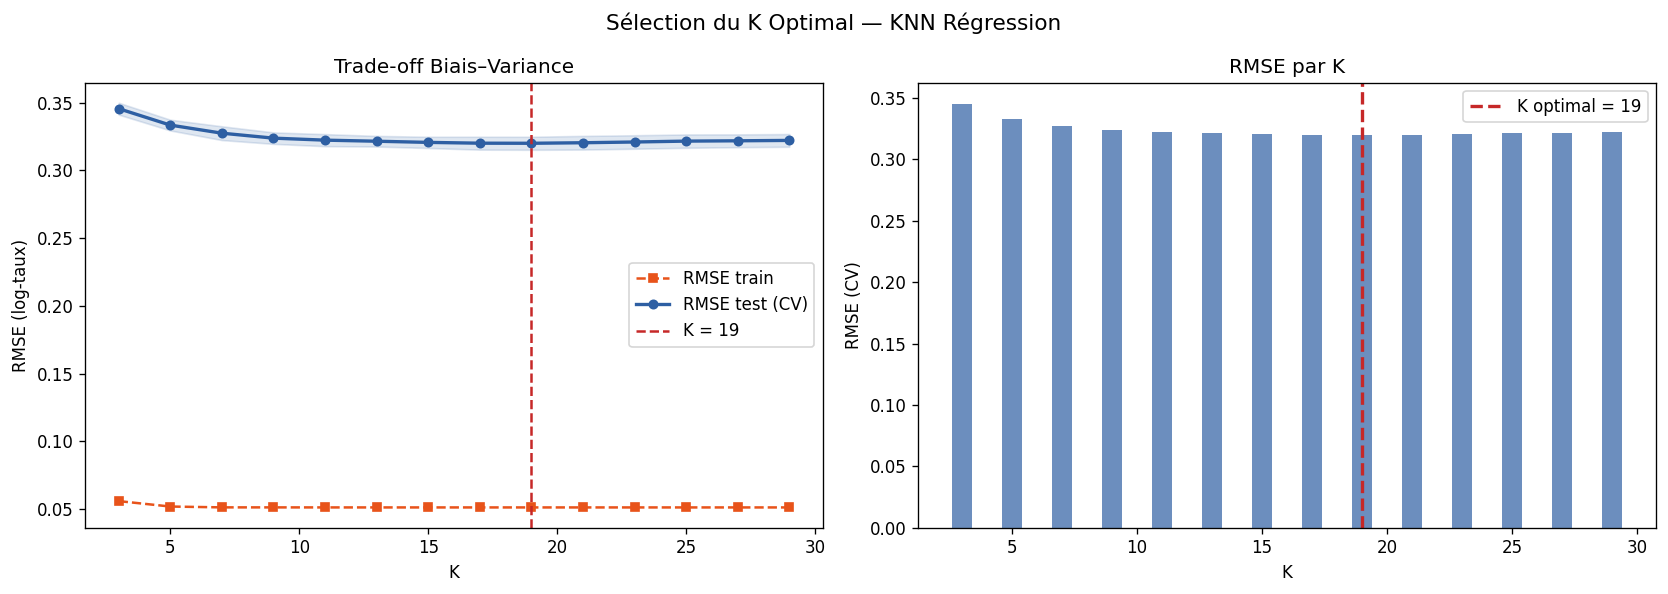


✅ Meilleur K = 19 (RMSE = 0.3199)


In [7]:
# Préparation pour la régression
data_reg = prepare_full(df, task='regression', encode_soil=True)

# Sélection K optimal (minimiser RMSE)
print('Régression — Recherche du K optimal (RMSE)...')
k_results_reg = find_best_k_regression(
    data_reg['X_train'], data_reg['y_train'],
    k_range=range(3, 31, 2), cv=5
)
fig = plot_k_regression(k_results_reg, save=True)
plt.show()

print(f'\n✅ Meilleur K = {k_results_reg["best_k"]} (RMSE = {k_results_reg["best_rmse"]:.4f})')

INFO |   🤖 Entraînement KNN Régression (K=19)...
INFO |   RMSE : 0.2919
INFO |   MAE  : 0.1415
INFO |   R²   : 0.7114
INFO |   Interprétation : RMSE ≈ 0.292 sur log-taux → erreur ≈ ×1.34 en échelle originale
INFO | 📊 Figure exportée → C:\Users\hp\Downloads\chlordecone-project\reports\figures\11_knn_regression_results.png


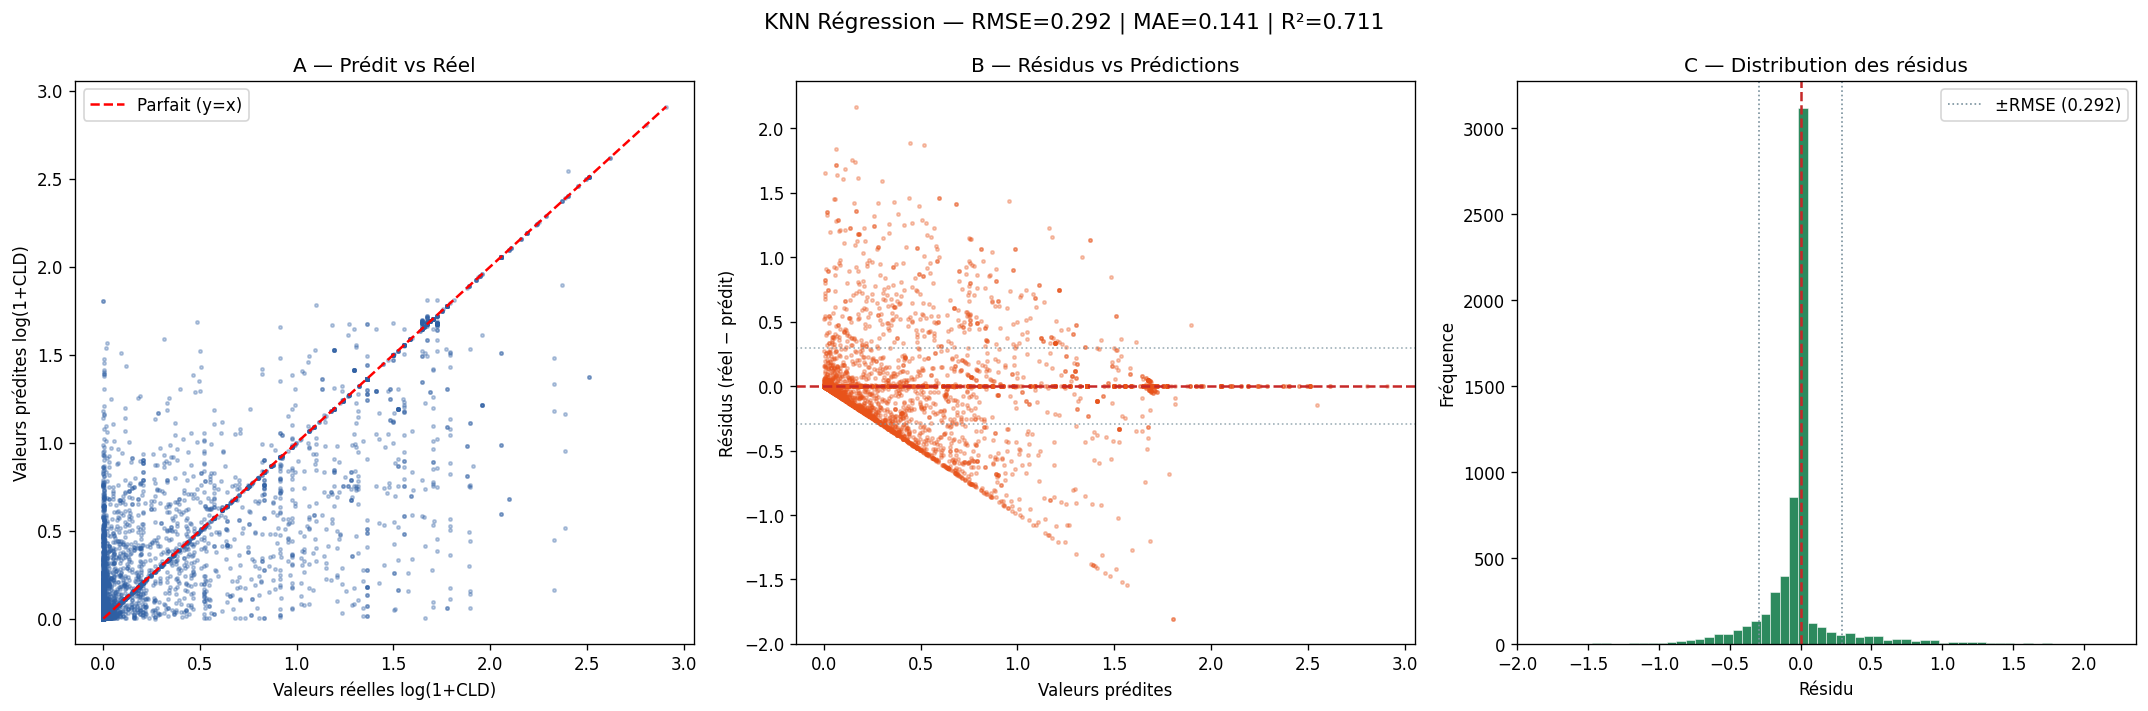


── Métriques finales ───────────────────────────────────────────
  RMSE : 0.2919 (sur log-taux)
  MAE  : 0.1415
  R²   : 0.7114
  Interprétation RMSE : erreur multiplicative ≈ ×1.34 sur échelle originale


In [8]:
# Entraînement KNN Régression
results_reg = train_evaluate_regression(
    data_reg['X_train'], data_reg['X_test'],
    data_reg['y_train'], data_reg['y_test'],
    best_k=k_results_reg['best_k']
)
fig = plot_regression_results(results_reg, data_reg['y_test'], save=True)
plt.show()

print(f'\n── Métriques finales ───────────────────────────────────────────')
print(f'  RMSE : {results_reg["rmse"]:.4f} (sur log-taux)')
print(f'  MAE  : {results_reg["mae"]:.4f}')
print(f'  R²   : {results_reg["r2"]:.4f}')
print(f'  Interprétation RMSE : erreur multiplicative ≈ ×{np.exp(results_reg["rmse"]):.2f} sur échelle originale')

### 💬 Lecture — KNN Régression

**RMSE (Root Mean Squared Error) :**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Le RMSE est exprimé dans la même unité que la variable cible : ici log(1+CLD).
Un RMSE = 0.35 sur log-taux correspond à une erreur multiplicative de e^0.35 ≈ ×1.4
sur l'échelle originale — le modèle peut se tromper d'un facteur 1.4 en moyenne.

**R² (coefficient de détermination) :**
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Un R² modéré est attendu : les variables topographiques seules n'expliquent
pas toute la variance de la contamination (d'autres facteurs jouent : type de sol,
doses historiques d'épandage, pratiques agricoles non modélisées).

**Courbe Biais-Variance :**
L'écart entre RMSE_train et RMSE_test révèle le degré d'overfitting :
- Grand écart (K petit) → overfitting
- Petit écart (K grand) → bon équilibre biais-variance

## 5. 🔬 Importance des Variables (Permutation Importance)

INFO |   🔬 Calcul de la permutation importance (20 répétitions)...
INFO | 
  Top 3 variables :
              feature  importance    std
HISTOBANANE_HISTO_BAN      0.2189 0.0044
   SOL_SIMPLE_ENCODED      0.1337 0.0045
     MNT_SHADING_MEAN      0.1197 0.0032
INFO | 📊 Figure exportée → C:\Users\hp\Downloads\chlordecone-project\reports\figures\09_feature_importance.png


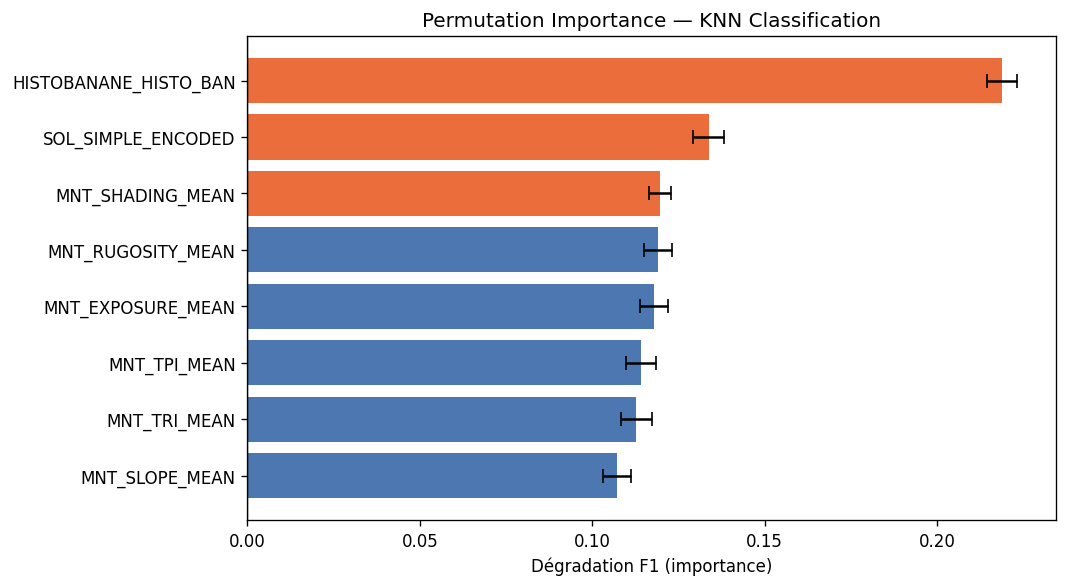


── Feature Importance (Permutation) ──────────────────────────
              feature  importance    std
HISTOBANANE_HISTO_BAN      0.2189 0.0044
   SOL_SIMPLE_ENCODED      0.1337 0.0045
     MNT_SHADING_MEAN      0.1197 0.0032
    MNT_RUGOSITY_MEAN      0.1191 0.0041
    MNT_EXPOSURE_MEAN      0.1179 0.0039
         MNT_TPI_MEAN      0.1142 0.0043
         MNT_TRI_MEAN      0.1128 0.0046
       MNT_SLOPE_MEAN      0.1071 0.0040


In [9]:
# Permutation importance sur le modèle de classification
importance_df = compute_feature_importance(
    results_clf['model'],
    data_clf['X_test'], data_clf['y_test'],
    data_clf['feature_names'],
    n_repeats=20,
    save=True
)
plt.show()

print('\n── Feature Importance (Permutation) ──────────────────────────')
print(importance_df.to_string(index=False))

### 💬 Lecture — Permutation Importance

**Principe :**
On mélange aléatoirement les valeurs d'une feature (20 répétitions).
La dégradation du F1-score = importance de cette feature.
Si mélanger une variable ne change pas le score, elle est inutile au modèle.

**Avantages vs coefficients linéaires :**
- Applicable à tout modèle (model-agnostic)
- Capture les effets non-linéaires et interactions
- Les barres d'erreur (±1σ sur 20 répétitions) quantifient la stabilité

**Interprétation attendue :**
- `HISTOBANANE_HISTO_BAN` : forte importance (proxy d'exposition historique)
- `SOL_SIMPLE_ENCODED` : forte importance (Andosols retiennent plus le CLD)
- Variables topographiques : importance variable selon le relief local

## 6. 📋 Tableau Comparatif — Classification vs Régression

| Aspect | KNN Classification | KNN Régression |
|---|---|---|
| **Cible** | DETECTED (0/1) | LOG_CHLD (continue) |
| **Prédiction** | Vote majoritaire pondéré | Moyenne pondérée |
| **K optimal** | Maximise F1 (CV 5-fold) | Minimise RMSE (CV 5-fold) |
| **Validation** | Stratifiée (classes déséquilibrées) | K-Fold standard |
| **Métriques** | Accuracy, F1, Précision, Rappel | RMSE, MAE, R² |
| **Utilité** | Détection/absence contamination | Estimation du niveau exact |
| **Erreur critique** | Faux Négatif (contaminé→propre) | RMSE × multiplicatif |

---

## 7. 📝 Conclusions de la Modélisation

1. **KNN Classification** : F1-score ~0.77 pour détecter les parcelles contaminées.
   Les variables historiques (HISTOBANANE) et pédologiques (type de sol) sont les plus
   discriminantes.

2. **KNN Régression** : R² modéré attendu — les features topographiques capturent
   une partie de la variance, mais l'histoire d'épandage locale (non observée)
   reste le facteur dominant.

3. **Limites du KNN** :
   - Coût de prédiction élevé (calcul de distances sur tout le train)
   - Sensible à la malédiction de la dimensionnalité (> 10 features)
   - Pas de modèle explicite (boîte noire)

4. **Pistes d'amélioration** :
   - Random Forest / XGBoost (robuste, gestion native des features catégorielles)
   - Krigeage (géostatistique, prend en compte la dépendance spatiale)
   - Variables supplémentaires : doses historiques d'épandage, distances aux parcelles traitées